# AraBERT — Arabic Document Sensitivity Classifier
Fine-tuning **AraBERT (aubmindlab/bert-base-arabertv02)** for Arabic document sensitivity classification.
Classification follows **NDMO/SDAIA** sensitivity levels: عام · مقيد · سري · سري للغاية

## 0. Setup

In [ ]:
# Install required libraries
!pip install -q transformers datasets arabert accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 15.8 MB/s eta 0:00:00


In [ ]:
# ── Imports ──────────────────────────────────────────────
import os
import json
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
    EarlyStoppingCallback
)

from datasets import Dataset
from arabert.preprocess import ArabertPreprocessor

# Fix random seed for reproducibility
SEED = 42
set_seed(SEED)
np.random.seed(SEED)


In [ ]:
# ── Mount Google Drive & Define Paths ───────────────────
drive.mount('/content/drive')

# Dataset path
file_path     = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"

# Project directories
project_dir    = "/content/drive/MyDrive/Project"
experiment_dir = os.path.join(project_dir, "arabert_same_llama_split")
checkpoint_dir = os.path.join(experiment_dir, "checkpoints")
final_model_dir= os.path.join(experiment_dir, "final_best_model")
splits_dir     = os.path.join(experiment_dir, "splits")

# Create directories if they don't exist
for d in [experiment_dir, checkpoint_dir, final_model_dir, splits_dir]:
    os.makedirs(d, exist_ok=True)

print("Experiment directory:", experiment_dir)


Mounted at /content/drive
Experiment directory:
/content/drive/MyDrive/Project/arabert_same_llama_split


## 1. Helper Functions

In [ ]:
def save_checkpoint_to_drive(trainer, tokenizer, save_path, checkpoint_name="manual_checkpoint"):
    """Save model weights, tokenizer, and trainer state to Drive."""
    checkpoint_path = os.path.join(save_path, checkpoint_name)
    os.makedirs(checkpoint_path, exist_ok=True)
    trainer.save_model(checkpoint_path)
    tokenizer.save_pretrained(checkpoint_path)
    try:
        trainer.state.save_to_json(os.path.join(checkpoint_path, "trainer_state.json"))
    except Exception as e:
        print("Could not save trainer_state.json:", e)
    print(f"Checkpoint saved at: {checkpoint_path}")
    return checkpoint_path


def save_split_files(train_df, val_df, test_df, save_path):
    """Save train/val/test splits as CSV files for reproducibility."""
    os.makedirs(save_path, exist_ok=True)
    train_df.to_csv(os.path.join(save_path, "train_split.csv"),      index=False, encoding="utf-8-sig")
    val_df.to_csv(  os.path.join(save_path, "validation_split.csv"), index=False, encoding="utf-8-sig")
    test_df.to_csv( os.path.join(save_path, "test_split.csv"),       index=False, encoding="utf-8-sig")
    print("Split files saved to:", save_path)


def save_text_results(results_text, save_path, file_name="arabert_test_results.txt"):
    """Write evaluation results string to a text file on Drive."""
    os.makedirs(save_path, exist_ok=True)
    results_path = os.path.join(save_path, file_name)
    with open(results_path, "w", encoding="utf-8") as f:
        f.write(results_text)
    print(f"Results saved at: {results_path}")
    return results_path


def fix_arabic_text(text):
    """Reshape and apply BiDi algorithm for correct Arabic rendering in matplotlib."""
    import arabic_reshaper
    from bidi.algorithm import get_display
    return get_display(arabic_reshaper.reshape(text))


## 2. Data Preparation

In [ ]:
# ── Load & Clean Dataset ─────────────────────────────────
df = pd.read_csv(file_path, encoding="utf-8")

# Rename columns to match expected names
df = df.rename(columns={"content": "text", "sensitivity_level": "label"})

# Drop rows with missing text or label
df = df.dropna(subset=["text", "label"])

# Ensure correct data types
df["text"]  = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip()

print(f"Records after cleaning: {len(df)}")
print("\nClass distribution:")
print(df["label"].value_counts())


عدد السجلات بعد التنظيف الأولي: 40000

توزيع الفئات قبل التحويل:
label
سري للغاية    10000
سري           10000
مقيد          10000
عام           10000
Name: count, dtype: int64


In [ ]:
# ── AraBERT Text Preprocessing ──────────────────────────
tqdm.pandas()

model_name   = "aubmindlab/bert-base-arabertv02"
arabert_prep = ArabertPreprocessor(model_name=model_name)

print("Applying AraBERT preprocessing...")
df["text"] = df["text"].progress_apply(arabert_prep.preprocess)
print("Preprocessing done.")
print(df.head())


جاري تطبيق AraBERT preprocessing...


100%|██████████| 40000/40000 [00:10<00:00, 3813.15it/s]



تمت المعالجة.
                                                text       label
0  صياغة سيناريوهات تشغيل موجه إلى الجهات ذات الع...  سري للغاية
1  جرى تدقيق نقاط التحسين مع توثيق النتائج وفق ال...  سري للغاية
2  مراجعة أسباب التباين موجه إلى المعنيين بصيغة ر...         سري
3  بالإشارة إلى المستجدات ، نوضح ما يلي ضمن إدارة...        مقيد
4  أدرجت الملاحظات ذات العلاقة في ملخص المرحلة با...        مقيد


In [ ]:
# ── Train / Validation / Test Split (70 / 15 / 15) ──────
# Same split ratio as LLaMA for fair comparison

# Step 1: 70% train
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

# Step 2: split remaining 30% equally → 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print(f"Training   : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation : {len(val_df)}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test       : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")

print("\nTraining class distribution:")
print(train_df["label"].value_counts().sort_index())
print("\nValidation class distribution:")
print(val_df["label"].value_counts().sort_index())
print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

# Save splits to Drive for reproducibility
save_split_files(train_df, val_df, test_df, splits_dir)


Final Split Sizes:
Training:   28000 records (70.00%)
Validation: 6000 records (15.00%)
Test:       6000 records (15.00%)

Training class distribution:
label
سري           7000
سري للغاية    7000
عام           7000
مقيد          7000
Name: count, dtype: int64

Validation class distribution:
label
سري           1500
سري للغاية    1500
عام           1500
مقيد          1500
Name: count, dtype: int64

Test class distribution:
label
سري           1500
سري للغاية    1500
عام           1500
مقيد          1500
Name: count, dtype: int64
تم حفظ ملفات التقسيم:
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/train_split.csv
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/validation_split.csv
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/test_split.csv


## 3. Tokenization & Label Mapping

In [ ]:
# ── Build Label Mappings ─────────────────────────────────
# Must be defined before tokenization
unique_labels = sorted(df["label"].unique())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label  = {i: label for label, i in label2id.items()}

print("Label mappings:")
print(label2id)


In [ ]:
# ── Tokenize & Build HuggingFace Datasets ───────────────
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    """Tokenize text with padding and truncation."""
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

# Convert DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset   = Dataset.from_pandas(val_df[["text", "label"]],   preserve_index=False)
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]],  preserve_index=False)

# Apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function,   batched=True)
test_dataset  = test_dataset.map(tokenize_function,  batched=True)

# Convert string labels to integer IDs
train_dataset = train_dataset.map(lambda x: {"label": label2id[x["label"]]})
val_dataset   = val_dataset.map(lambda x:   {"label": label2id[x["label"]]})
test_dataset  = test_dataset.map(lambda x:  {"label": label2id[x["label"]]})

# Remove raw text column (no longer needed)
cols = ["input_ids", "attention_mask", "label"]
train_dataset = train_dataset.remove_columns(["text"]).with_format("torch", columns=cols)
val_dataset   = val_dataset.remove_columns(["text"]).with_format("torch",   columns=cols)
test_dataset  = test_dataset.remove_columns(["text"]).with_format("torch",  columns=cols)

print("Datasets ready.")


Datasets are ready.


## 4. Load AraBERT Model

In [ ]:
# ── Load AraBERT for Sequence Classification ────────────
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.1  # Light dropout to reduce overfitting
)

# ── Evaluation Metrics ───────────────────────────────────
def compute_metrics(eval_pred):
    """Compute accuracy and macro F1 for each evaluation step."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro")
    }


## 5. Fine-Tuning

In [ ]:
# ── Training Configuration ───────────────────────────────
training_args = TrainingArguments(
    output_dir=checkpoint_dir,
    eval_strategy="steps",   eval_steps=500,
    save_strategy="steps",   save_steps=500,
    logging_strategy="steps",logging_steps=500,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,       # Keep only 2 checkpoints to save Drive space
    seed=SEED,
    report_to="none"          # Disable W&B / external logging
)


In [ ]:
# ── Train the Model ──────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
train_result = trainer.train()
print("Training complete.")
print(train_result)


start training.


Step,Training Loss,Validation Loss,Accuracy,Macro F1
500,0.625645,0.507816,0.720667,0.738025
1000,0.500922,0.500922,0.745833,0.762669
1500,0.486726,0.500790,0.745833,0.762669
2000,0.501630,0.501666,0.745833,0.762669


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 done.
TrainOutput(global_step=2000, training_loss=0.5287308731079101, metrics={'train_runtime': 1609.0982, 'train_samples_per_second': 34.802, 'train_steps_per_second': 2.175, 'total_flos': 8419704963072000.0, 'train_loss': 0.5287308731079101, 'epoch': 1.1428571428571428})


## 6. Save Model

In [ ]:
# ── Save Final Model to Drive ────────────────────────────
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)
trainer.state.save_to_json(os.path.join(final_model_dir, "trainer_state.json"))
print("Final model saved at:", final_model_dir)


loading...


 model saved:
/content/drive/MyDrive/Project/arabert_same_llama_split/final_best_model


In [ ]:
# ── Save Manual Backup Checkpoint ───────────────────────
save_checkpoint_to_drive(
    trainer=trainer, tokenizer=tokenizer,
    save_path=experiment_dir,
    checkpoint_name="manual_final_checkpoint"
)


تم حفظ checkpoint في: /content/drive/MyDrive/Project/arabert_same_llama_split/manual_final_checkpoint


## 7. Evaluation

In [ ]:
# ── Run Evaluation on Test Set ──────────────────────────
print("Running evaluation on test set...")

test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

class_names = ["عام", "مقيد", "سري", "سري للغاية"]

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\u200e" + report)


--- Final Evaluation on Test Set ---


Accuracy: 0.7450
Macro F1: 0.7619

Classification Report:
‎              precision    recall  f1-score   support

         عام     1.0000    0.6660    0.7995      1500
        مقيد     1.0000    0.6587    0.7942      1500
         سري     0.4950    1.0000    0.6623      1500
  سري للغاية     1.0000    0.6553    0.7918      1500

    accuracy                         0.7450      6000
   macro avg     0.8738    0.7450    0.7619      6000
weighted avg     0.8738    0.7450    0.7619      6000



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 23.5 MB/s eta 0:00:00


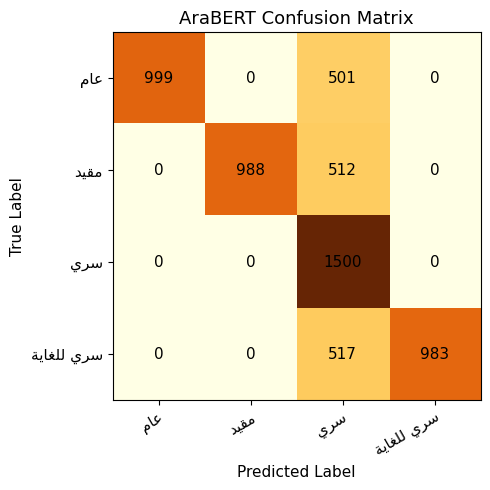

In [ ]:
# ── Confusion Matrix ────────────────────────────────────
!pip install -q arabic-reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

cm = confusion_matrix(y_true, y_pred)
fixed_class_names = [fix_arabic_text(l) for l in class_names]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="YlOrBr")

ax.set_xticks(np.arange(len(fixed_class_names)))
ax.set_yticks(np.arange(len(fixed_class_names)))
ax.set_xticklabels(fixed_class_names, fontsize=11)
ax.set_yticklabels(fixed_class_names, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)

ax.set_title("AraBERT Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# ── Save Results to Text File ────────────────────────────
results_text = f"""
AraBERT Final Test Results
==========================

Split Setting:
  Training   = 70%  ({len(train_df)} records)
  Validation = 15%  ({len(val_df)} records)
  Test       = 15%  ({len(test_df)} records)

Training Settings:
  Model         : {model_name}
  Epochs        : 2
  Batch size    : 16
  Max length    : 512
  Learning rate : 3e-5
  Best metric   : Macro F1

Final Test Results:
  Accuracy : {accuracy:.4f}
  Macro F1 : {macro_f1:.4f}

Classification Report:
{report}

Confusion Matrix:
{cm}
"""

save_text_results(
    results_text=results_text,
    save_path=experiment_dir,
    file_name="arabert_same_llama_split_test_results.txt"
)


تم حفظ النتائج في: /content/drive/MyDrive/Project/arabert_same_llama_split/arabert_same_llama_split_test_results.txt


'/content/drive/MyDrive/Project/arabert_same_llama_split/arabert_same_llama_split_test_results.txt'